In [3]:
!pip install yfinance

# use your mobile data to install yfiannce

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8")


In [5]:
start_date = "2025-03-04"
end_date = "2026-03-04"

hdfc = yf.download("HDFCBANK.NS", start=start_date, end=end_date)['Close']
sparc = yf.download("SPARC.NS", start=start_date, end=end_date)['Close']

df = pd.concat([hdfc, sparc], axis=1)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [6]:
df.to_csv("HDFC_SPARC_Closing_Prices.csv", index=True)

In [7]:
df.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,247.000000,247.000000
mean,958.176712,143.411903
std,42.404946,13.075051
min,831.510498,117.250000
25%,940.867706,133.504997
50%,965.250000,141.899994
75%,992.140472,151.560005
max,1012.900024,198.539993


<Figure size 1000x600 with 0 Axes>

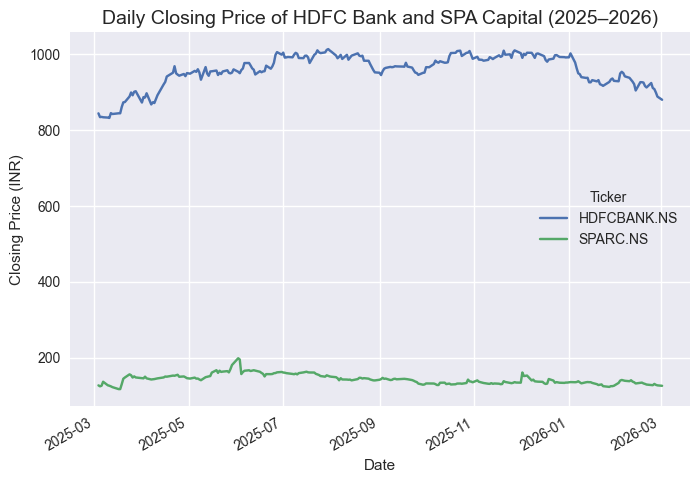

<Figure size 800x550 with 0 Axes>

In [8]:
plt.figure(figsize=(10,6))

df.plot()

plt.title("Daily Closing Price of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid(True)

plt.show()
plt.savefig('daily_closing_price_of_HDFC_Bank_and_SPA_Capital.png')


In [9]:
returns = df.pct_change()
returns.head()

Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-03-04,NaN,NaN
2025-03-05,-0.011696,-0.019207
2025-03-06,0.000710,0.011637
2025-03-07,-0.001153,0.083697
2025-03-10,-0.001036,-0.067716


In [10]:
returns = returns.dropna()
returns.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,246.000000,246.000000
mean,0.000214,0.000431
std,0.009506,0.030729
min,-0.033011,-0.196485
25%,-0.005338,-0.014173
50%,-0.000203,-0.002708
75%,0.006059,0.007959
max,0.035720,0.199940


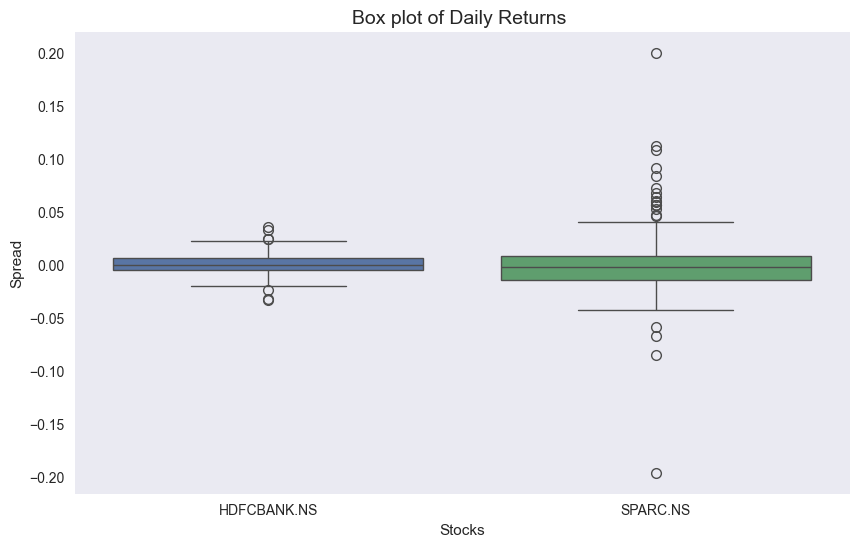

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(data=returns)

plt.title("Box plot of Daily Returns ", fontsize=14)
plt.xlabel("Stocks")
plt.ylabel("Spread")
plt.grid(axis='y')

plt.show()

<Figure size 1000x600 with 0 Axes>

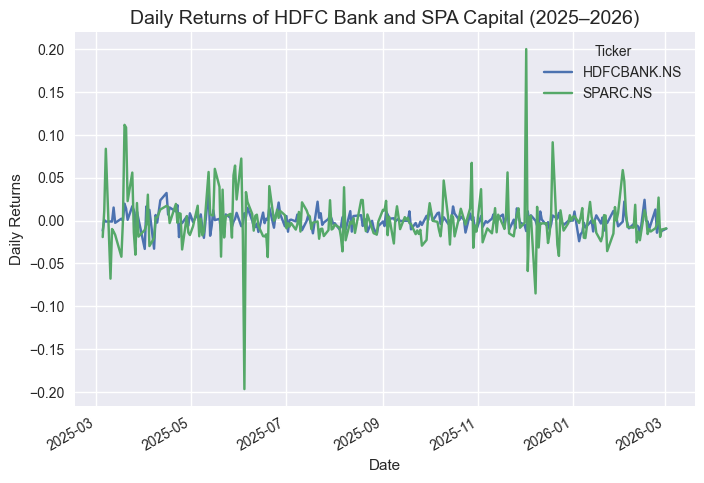

In [12]:
plt.figure(figsize=(10,6))
returns.plot()
plt.title("Daily Returns of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.ylabel("Daily Returns")
plt.xlabel("Date")
plt.grid(True)
plt.show()


### Compounding Returns

In [13]:
Compounded_returns = (((returns+1).prod()-1)*100).round(2)
Compounded_returns

Ticker
HDFCBANK.NS    4.24
SPARC.NS      -0.88
dtype: float64

### Annualized Returns

In [14]:
annualized_return = Compounded_returns

### Annualized Volatility (Converting volatility for a daily series to yearly)

In [15]:
annualized_vol = returns.std() * (returns.shape[1] ** 0.5)
annualized_vol

Ticker
HDFCBANK.NS    0.013443
SPARC.NS       0.043457
dtype: float64

### Skewness

In [16]:
skewness = returns.skew()
skewness

Ticker
HDFCBANK.NS    0.167469
SPARC.NS       0.681570
dtype: float64

### Kurtosis

In [17]:
kurtosis = returns.kurt()
kurtosis

Ticker
HDFCBANK.NS     1.639738
SPARC.NS       14.618389
dtype: float64

### Return Risk Ratio


In [18]:
return_risk_ratio = annualized_return / annualized_vol
return_risk_ratio


Ticker
HDFCBANK.NS    315.404645
SPARC.NS       -20.249840
dtype: float64

### Maximum Drawdown and Wealth Index

In [19]:
wealth_index = (1 + returns).cumprod()
wealth_index.head()


Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-03-05,0.988304,0.980793
2025-03-06,0.989006,0.992207
2025-03-07,0.987865,1.075252
2025-03-10,0.986842,1.002440
2025-03-11,0.985673,0.992601


<Figure size 1000x600 with 0 Axes>

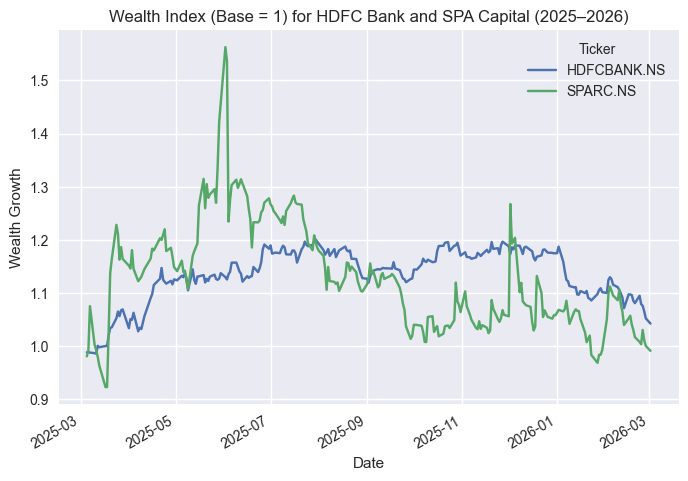

In [20]:
plt.figure(figsize=(10,6))

wealth_index.plot()

plt.title("Wealth Index (Base = 1) for HDFC Bank and SPA Capital (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Wealth Growth")
plt.grid(True)

plt.show()


In [21]:
running_max = wealth_index.cummax()


In [22]:
drawdown = wealth_index / running_max - 1

In [23]:
max_drawdown = drawdown.min()
max_drawdown


Ticker
HDFCBANK.NS   -0.131800
SPARC.NS      -0.380226
dtype: float64

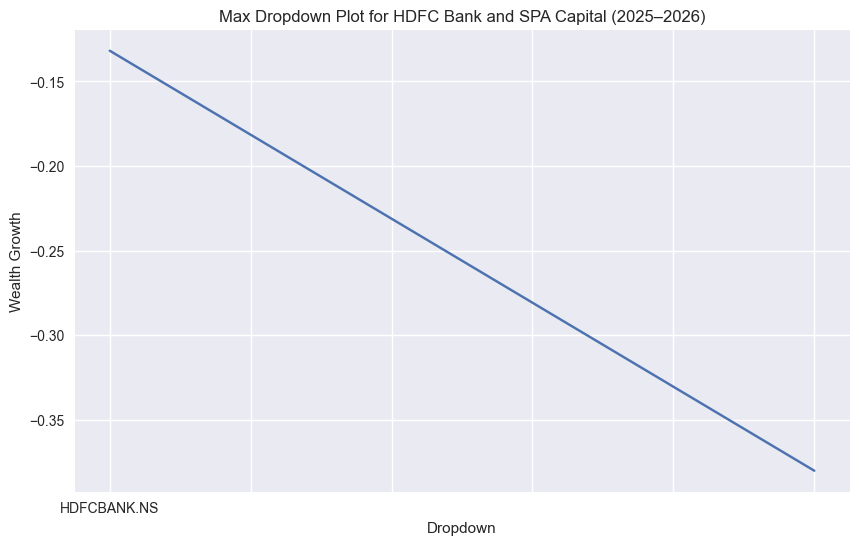

In [29]:
plt.figure(figsize=(10,6))

max_drawdown.plot()

plt.title("Max Dropdown Plot for HDFC Bank and SPA Capital (2025–2026)")
plt.xlabel("Dropdown")
plt.ylabel("Wealth Growth")
plt.grid(True)

plt.show()
